## Activation Function:
- An activation function is a mathematical function applied to the output of a neuron in a neural network.
  
- It introduces non-linearity into the model, allowing it to learn complex patterns and relationships in the data.

- Common activation functions include:
  - **Sigmoid**: Maps input values to a range between 0 and 1, often used in binary classification problems.
  
  - **ReLU (Rectified Linear Unit)**: Outputs the input directly if it is positive; otherwise, it outputs zero. It is widely used in hidden layers of neural networks.
  
  - **Tanh (Hyperbolic Tangent)**: Maps input values to a range between -1 and 1, often used in hidden layers of neural networks.
  
  - **Softmax**: Converts a vector of values into a probability distribution, commonly used in the output layer for multi-class classification problems.
  
  - **Leaky ReLU**: Similar to ReLU but allows a small, non-zero gradient when the input is negative, helping to prevent the "dying ReLU" problem.
- The choice of activation function can significantly impact the performance and convergence of a neural network model.

- Activation functions are essential for enabling neural networks to capture complex patterns and make accurate predictions.

- In summary, activation functions play a crucial role in the functioning of neural networks by introducing non-linearity, allowing the model to learn and represent complex relationships in the data.

### ACtivation functions : RELU
- ReLU (Rectified Linear Unit) is a widely used activation function in neural networks, especially in hidden layers.
- The ReLU function is defined as:
  
  ```
  f(x) = max(0, x)
  ```
- This means that if the input `x` is positive, the output is `x`, and if the input is negative, the output is `0`.
- ReLU is computationally efficient and helps to mitigate the vanishing gradient problem, which can occur with other activation functions like sigmoid or tanh.
- However, ReLU can suffer from the "dying ReLU" problem, where neurons can become inactive and only output zero for all inputs. To address this issue, variants like Leaky ReLU have been developed, which allow a small, non-zero gradient when the input is negative.
- Overall, ReLU is a popular choice for activation functions in deep learning models due to its simplicity and effectiveness in training deep neural networks.

In [25]:
import numpy as np
from nnfs.datasets import spiral_data

In [26]:
inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
output = np.maximum(0, inputs)
print(output)

[0.  2.  0.  3.3 0.  1.1 2.2 0. ]


In [27]:
# ReLU activation function
class Activation_ReLU:
    # Forward Pass
    def forward(self, inputs):
        # Calculate output values from inputs
        self.output = np.maximum(0, inputs)

In [28]:
# Dense Layer Class
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        
    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases

In [29]:
# Create Datasets
x, y = spiral_data(samples=100, classes=3)

# Create Dense Layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)

# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()

# Make a forward pass of our training data through this layer
dense1.forward(x)

# Foeward pass through activation function
# Take in the output of the dense layer here and perform a forward pass through the activation function
activation1.forward(dense1.output)

# Let's print the output of the activation function
print(activation1.output[:5])

[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.57351782e-06 1.08718871e-04 0.00000000e+00]
 [0.00000000e+00 1.58661385e-04 2.97644513e-04]
 [0.00000000e+00 1.43574518e-04 6.22930286e-04]
 [0.00000000e+00 3.63081358e-04 4.55830737e-04]]


### Activation functions : SOFTMAX
- The Softmax activation function is commonly used in the output layer of neural networks for multi-class classification problems.
- The Softmax function converts a vector of raw scores (logits) into a probability distribution over multiple classes. It is defined as:
  
  ```
  f(x_i) = exp(x_i) / sum(exp(x_j)) for j = 1 to N
  ```
  
  where `x_i` is the input score for class `i`, and `N` is the total number of classes.
- The Softmax function ensures that the output values are between 0 and 1, and that they sum up to 1, making it suitable for interpreting the outputs as probabilities.
- In a multi-class classification problem, the class with the highest probability output from the Softmax function is typically chosen as the predicted class.
- The Softmax function is essential for training neural networks on multi-class classification tasks, as it allows the model to learn to assign probabilities to each class, enabling it to make informed predictions based on the input data.
- In summary, the Softmax activation function is a crucial component in multi-class classification problems, providing a way to convert raw scores into probabilities that can be used for making predictions.

In [30]:
inputs = [[1, 2, 3, 2.5],
          [2.0, 5.0, -1.0, 2.0],
          [-1.5, 2.7, 3.3, -0.8]]

# Get unnormalized probabilities
exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))

# Normalize them for each sample
probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
print(probabilities)
np.sum(probabilities, axis=1)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


array([1., 1., 1.])

In [31]:
# Softmax Activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # Get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        # Normalize them for each sample
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

In [32]:
# Create Datasets
x, y = spiral_data(samples=100, classes=3)
# Create Dense Layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create Softmax activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features and 3 output values
dense2 = Layer_Dense(3, 3)

# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer
dense1.forward(x)

# Make a forward pass through activation function
# it takes the output of the dense layer here and performs a forward pass through the activation function
activation1.forward(dense1.output)

# Make a forward pass through the second Dense layer
# it takes the output of the activation function of the first layer as input
dense2.forward(activation1.output)
# Make a forward pass through the activation function
# it takes the output of the second dense layer here and performs a forward pass through the activation

# Make a forward pass through the activation function
# it takes the output of the second dense layer here and performs a forward pass through the activation function
activation2.forward(dense2.output)
# Let's print the output of the activation function
print(activation2.output[:5])


[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333324 0.33333343]
 [0.33333293 0.3333328  0.33333427]
 [0.3333323  0.33333248 0.33333522]
 [0.33333204 0.33333267 0.33333529]]


## Visualize the Neural Network (from the last cell)

This section visualizes the same model pipeline used in the last code cell:

Input (2 features) -> Dense(2, 3) -> ReLU -> Dense(3, 3) -> Softmax

The code below shows:
- True class distribution of the spiral dataset
- Predicted classes from the current network output
- A simple architecture diagram of the network

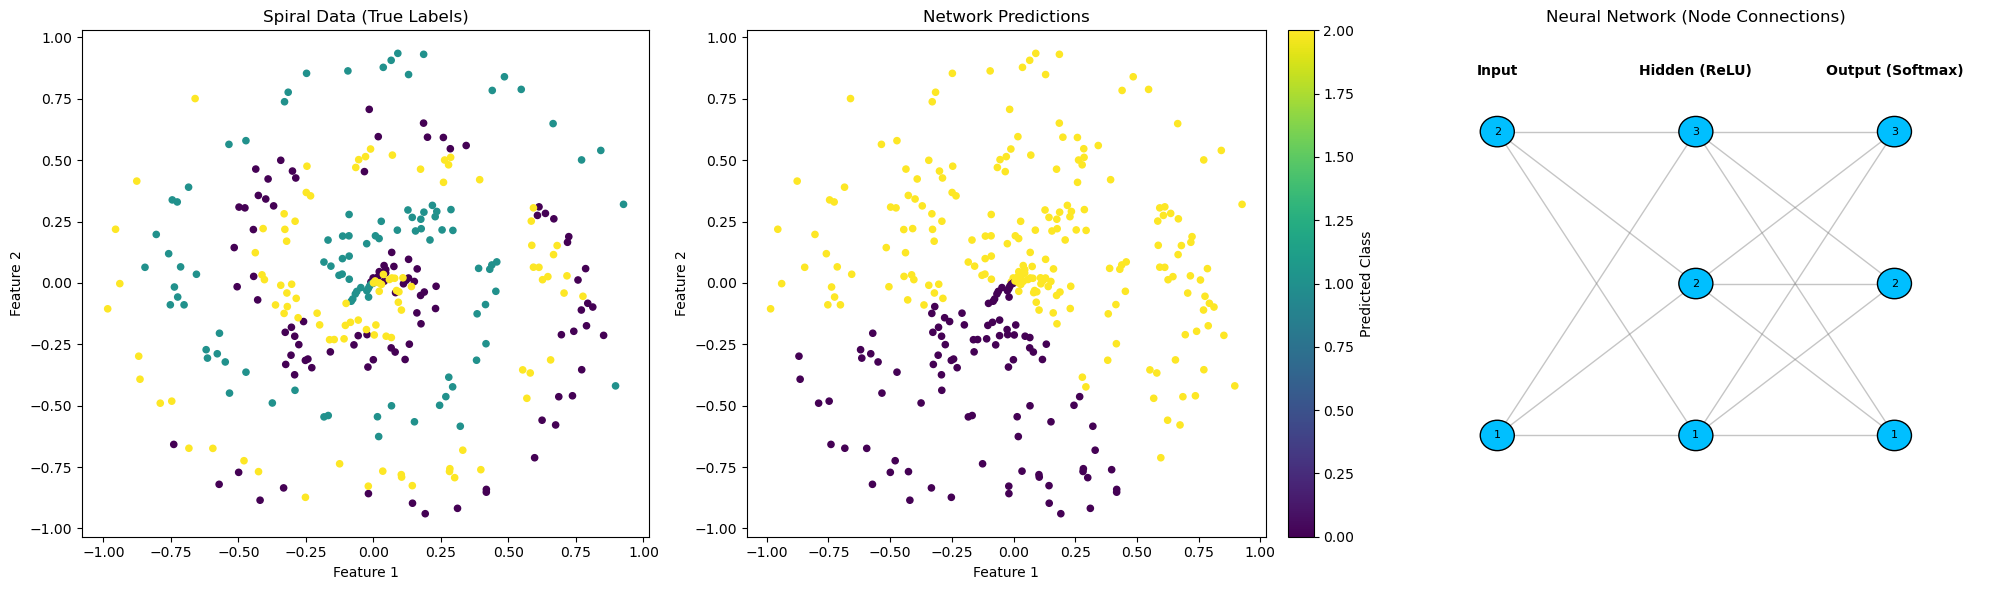

First 5 softmax outputs:
[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333324 0.33333343]
 [0.33333293 0.3333328  0.33333427]
 [0.3333323  0.33333248 0.33333522]
 [0.33333204 0.33333267 0.33333529]]
First 5 confidence values:
[0.33333333 0.33333343 0.33333427 0.33333522 0.33333529]


In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# Run the same forward pipeline from the last model cell
dense1.forward(x)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

pred_classes = np.argmax(activation2.output, axis=1)
confidences = np.max(activation2.output, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) True classes
axes[0].scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', s=20)
axes[0].set_title('Spiral Data (True Labels)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# 2) Predicted classes
sc = axes[1].scatter(x[:, 0], x[:, 1], c=pred_classes, cmap='viridis', s=20)
axes[1].set_title('Network Predictions')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
plt.colorbar(sc, ax=axes[1], fraction=0.046, pad=0.04, label='Predicted Class')

# 3) Node-to-node neural network diagram
ax = axes[2]
ax.set_title('Neural Network (Node Connections)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Architecture used in last cell: 2 -> 3 -> 3
layer_sizes = [2, 3, 3]
layer_names = ['Input', 'Hidden (ReLU)', 'Output (Softmax)']
x_positions = [0.15, 0.5, 0.85]

def y_positions(n):
    # Evenly place nodes vertically
    return np.linspace(0.2, 0.8, n)

node_positions = []
for x_pos, n_nodes in zip(x_positions, layer_sizes):
    ys = y_positions(n_nodes)
    node_positions.append([(x_pos, y) for y in ys])

# Draw full connections between consecutive layers
for layer_idx in range(len(node_positions) - 1):
    for x1, y1 in node_positions[layer_idx]:
        for x2, y2 in node_positions[layer_idx + 1]:
            ax.plot([x1, x2], [y1, y2], color='gray', alpha=0.45, linewidth=1)

# Draw nodes
for layer_idx, nodes in enumerate(node_positions):
    for node_idx, (xn, yn) in enumerate(nodes):
        circle = Circle((xn, yn), 0.03, facecolor='deepskyblue', edgecolor='black', zorder=3)
        ax.add_patch(circle)
        ax.text(xn, yn, f'{node_idx + 1}', ha='center', va='center', fontsize=8, zorder=4)

# Draw layer labels
for x_pos, label in zip(x_positions, layer_names):
    ax.text(x_pos, 0.92, label, ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('First 5 softmax outputs:')
print(activation2.output[:5])
print('First 5 confidence values:')
print(confidences[:5])